In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('../data/processed/clnopr.csv')
df = df.convert_dtypes()

In [7]:
print(df.shape)

(11050, 30)


In [8]:
# print("-------------\n Unique Values \n------------")
print(df.nunique().sort_values(ascending=False))

Unnamed: 0             11050
op_id                  11050
subject_id             11050
hadm_id                11050
icd10_pcs                547
opend_time               345
anend_time               345
orout_time               335
anstart_time             293
opstart_time             290
preop_wait_time          290
orin_time                285
risk_x_duration          216
bmi                      141
anesthesia_duration      133
surgery_duration         122
age                       15
height                    14
weight                    14
department                12
asa                        6
antype                     4
age_group                  4
bmi_category               4
sex                        2
emop                       2
high_risk                  2
mortality                  2
opdate                     1
admission_time             1
dtype: int64


In [9]:
# print("-------------\n Null values \n------------")
print((df.isnull().mean().mul(100).round(2)).sort_values(ascending=False))

Unnamed: 0             0.0
op_id                  0.0
subject_id             0.0
hadm_id                0.0
opdate                 0.0
age                    0.0
sex                    0.0
weight                 0.0
height                 0.0
asa                    0.0
emop                   0.0
department             0.0
antype                 0.0
icd10_pcs              0.0
orin_time              0.0
orout_time             0.0
opstart_time           0.0
opend_time             0.0
admission_time         0.0
anstart_time           0.0
anend_time             0.0
mortality              0.0
surgery_duration       0.0
anesthesia_duration    0.0
preop_wait_time        0.0
bmi                    0.0
bmi_category           0.0
high_risk              0.0
age_group              0.0
risk_x_duration        0.0
dtype: float64


In [11]:
df[['opdate','admission_time','orin_time','anstart_time','opstart_time','anend_time','opend_time','orout_time']].describe()

,opdate,admission_time,orin_time,anstart_time,opstart_time,anend_time,opend_time,orout_time
count,11050.0,11050.0,11050.0,11050.0,11050.0,11050.0,11050.0,11050.0
mean,0.0,0.0,46570.235294,47037.963801,48136.153846,51710.38914,51648.108597,51976.099548
std,0.0,0.0,14916.344334,14950.15789,15238.12374,17115.1875,17099.583867,17233.669501
min,0.0,0.0,0.0,300.0,1800.0,3900.0,3300.0,3600.0
25%,0.0,0.0,35700.0,36000.0,36900.0,39000.0,39000.0,39000.0
50%,0.0,0.0,45000.0,45300.0,46200.0,48600.0,48600.0,48600.0
75%,0.0,0.0,55200.0,55500.0,56700.0,60000.0,60000.0,60300.0
max,0.0,0.0,96600.0,96600.0,99300.0,146400.0,171300.0,172200.0


In [12]:
df['mortality'].value_counts(normalize=True)

mortality
0    0.98905
1    0.01095
Name: proportion, dtype: Float64

In [13]:
df.groupby('mortality')['asa'].mean()

mortality
0    1.745905
1    2.454545
Name: asa, dtype: Float64

In [14]:
df.groupby('mortality')['age'].mean()

mortality
0    57.503889
1    65.371901
Name: age, dtype: Float64

<Axes: xlabel='surgery_duration', ylabel='Count'>

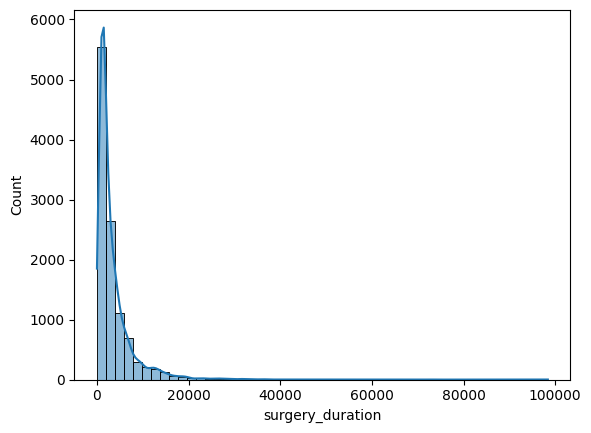

In [15]:
sns.histplot(df['surgery_duration'], bins=50, kde=True)

In [16]:
df.corr(numeric_only=True)

,Unnamed: 0,op_id,subject_id,hadm_id,opdate,age,weight,height,asa,emop,...,admission_time,anstart_time,anend_time,mortality,surgery_duration,anesthesia_duration,preop_wait_time,bmi,high_risk,risk_x_duration
Unnamed: 0,1.000000,-0.011319,0.012003,-0.000096,NaN,0.057068,0.028294,-0.000357,0.083826,-0.062143,...,NaN,0.023419,-0.006975,-0.020386,-0.087365,-0.095953,0.017176,0.029840,0.094325,-0.045401
op_id,-0.011319,1.000000,-0.017441,-0.020333,NaN,0.006428,-0.012570,-0.003538,-0.004669,-0.006219,...,NaN,-0.016082,-0.013064,-0.017758,0.000840,0.003440,-0.015468,-0.011645,-0.006895,0.000593
subject_id,0.012003,-0.017441,1.000000,0.023650,NaN,0.020347,-0.006088,-0.008520,0.015176,-0.016039,...,NaN,-0.012760,-0.014880,-0.012189,-0.013285,-0.013063,-0.012872,0.000441,0.004895,-0.009442
hadm_id,-0.000096,-0.020333,0.023650,1.000000,NaN,0.018676,-0.009167,-0.010801,0.000354,-0.009689,...,NaN,-0.010772,-0.014473,-0.002122,-0.020563,-0.017713,-0.011062,-0.000885,-0.007834,-0.019155
opdate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,0.057068,0.006428,0.020347,0.018676,NaN,1.000000,-0.195265,-0.364248,0.331736,-0.241856,...,NaN,-0.167024,-0.196867,0.045718,-0.144911,-0.178300,-0.175735,0.048714,0.114251,-0.034656
weight,0.028294,-0.012570,-0.006088,-0.009167,NaN,-0.195265,1.000000,0.586315,-0.051056,0.006249,...,NaN,0.037901,0.042360,-0.045508,0.026899,0.032369,0.038550,0.764624,-0.049000,0.003195
height,-0.000357,-0.003538,-0.008520,-0.010801,NaN,-0.364248,0.586315,1.000000,-0.108256,0.137012,...,NaN,0.100592,0.135491,0.022224,0.148563,0.166588,0.107142,-0.064220,-0.004709,0.096281
asa,0.083826,-0.004669,0.015176,0.000354,NaN,0.331736,-0.051056,-0.108256,1.000000,0.157014,...,NaN,0.054759,0.095480,0.119770,0.169801,0.166671,0.059981,0.025980,0.640440,0.420880
emop,-0.062143,-0.006219,-0.016039,-0.009689,NaN,-0.241856,0.006249,0.137012,0.157014,1.000000,...,NaN,0.466330,0.576356,0.141911,0.536391,0.591220,0.489943,-0.094117,0.177852,0.481478


<Axes: xlabel='mortality', ylabel='surgery_duration'>

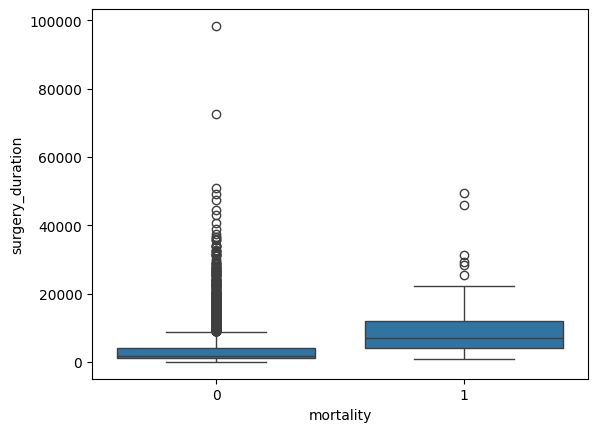

In [17]:
sns.boxplot(x='mortality', y=df['surgery_duration'], data=df)

In [18]:
pd.crosstab(df['asa'], df['mortality'], normalize='index')

mortality,0,1
asa,,
1,0.997822,0.002178
2,0.990351,0.009649
3,0.948617,0.051383
4,0.881579,0.118421
5,0.833333,0.166667
6,1.000000,0.000000
